In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle


In [3]:
# #unzipping dataset
# import shutil

# shutil.unpack_archive('face_mask_dataset.zip')


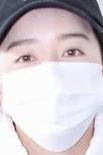

In [4]:
# load image using keras utility function

tf.keras.utils.load_img('face_mask_dataset/train/with_mask/with_mask_50.jpg')

In [5]:
# ✅ Step 1 - Data Load
data = []
labels = []

categories = ["with_mask", "without_mask"]
path = "face_mask_dataset/train"

for category in categories:
    folder = os.path.join(path, category)
    label = categories.index(category)

    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))
            data.append(img)
            labels.append(label)
        except:
            pass

data = np.array(data) / 255.0
labels = np.array(labels)

In [6]:

data, labels = shuffle(data, labels, random_state=42)

print(f"Total images: {len(data)}")
print(f"With mask: {np.sum(labels == 0)}, Without mask: {np.sum(labels == 1)}")



Total images: 6324
With mask: 3086, Without mask: 3238


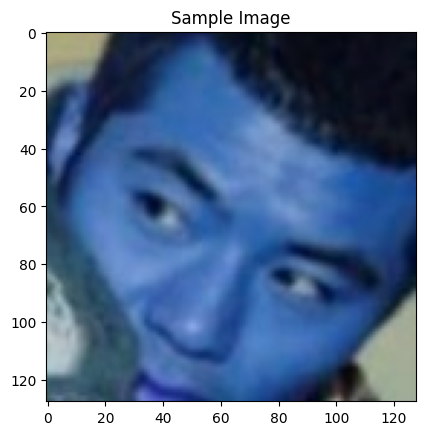

In [7]:
plt.imshow(data[0])
plt.title("Sample Image")
plt.show()

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [10]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Dense
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))

# Output
model.add(Dense(1, activation='sigmoid'))

C:\Users\MUZZAMMIL AHMED\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]   
)

Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 152s 882ms/step - accuracy: 0.7786 - loss: 1.2028 - val_accuracy: 0.5217 - val_loss: 6.2139
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 131s 823ms/step - accuracy: 0.8247 - loss: 0.4234 - val_accuracy: 0.6901 - val_loss: 1.3098
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 138s 799ms/step - accuracy: 0.8616 - loss: 0.3146 - val_accuracy: 0.8055 - val_loss: 0.5177
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 142s 797ms/step - accuracy: 0.8672 - loss: 0.3153 - val_accuracy: 0.8308 - val_loss: 0.5784
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 146s 823ms/step - accuracy: 0.8680 - loss: 0.3373 - val_accuracy: 0.8403 - val_loss: 0.5343


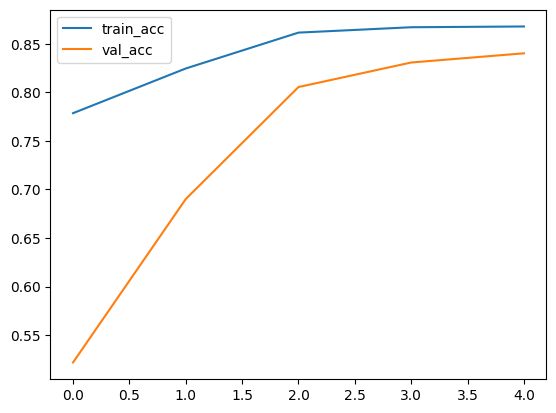

In [13]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [14]:
model.save("mask_detector.keras")

In [15]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))

    pred = model.predict(img)

    return "Without Mask" if pred > 0.5 else "With Mask"

In [16]:
print(predict_image("face_mask_dataset/test/with_mask/with_mask_260.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
With Mask


###### 